<a href="https://colab.research.google.com/github/Mati-D/customer-churn-mlops/blob/main/notebooks/01_eda_y_modelado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://images.unsplash.com/photo-1551836022-d5d88e9218df?w=1200&auto=format&fit=crop&q=80" width="100%" style="border-radius: 8px;">

# 📊 Telecom Customer Churn Prediction & MLOps Pipeline
> **Autor:** Matías Díaz  
> **Área:** Customer Analytics & Predictive Modeling  
> **Stack:** Python, Pandas, Scikit-Learn, MLflow, SHAP  

---

### 📋 Descripción del Problema de Negocio
La pérdida de clientes (*Churn*) es una de las métricas más críticas en el sector de telecomunicaciones. Retener un cliente existente cuesta significativamente menos que adquirir uno nuevo.

**Objetivos del Proyecto:**
1. **Identificar patrones clave** de comportamiento asociados a la cancelación del servicio.
2. **Construir un modelo predictivo** optimizado para maximizar la detección temprana de clientes en riesgo (métrica objetivo: *ROC-AUC* / *Recall*).
3. **Explicar las predicciones** mediante técnicas de interpretabilidad (SHAP) para sugerir estrategias de retención automatizadas.

---

# 1. Carga de Datos y Radiografía Inicial (EDA)

In [1]:
import numpy as np
import pandas as pd

# Leemos el dataset directamente desde la fuente
data = pd.read_csv("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv")

# Muestra las primeras 5 filas
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Tamanio del dataset
data.shape

(7043, 21)

In [3]:
# 1. Información general de columnas y tipos de datos
print("--- Información del Dataset ---")
data.info()

# 2. Distribución de la variable objetivo
print("\n--- Porcentaje de Churn ---")
print(data['Churn'].value_counts(normalize=True) * 100)

--- Información del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessB

In [4]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# 2. Limpieza de Datos y Preprocesamiento Base

In [5]:
# 1. Eliminar identificador que no aporta al modelo, no tiene valor predictivo y puede generar overfitting.
df_clean = data.drop(columns=['customerID']).copy()

# 2. Corregir TotalCharges (convertir texto con espacios a valores numéricos), vimos que esta como object y necesitamos verla como numerica para realizar operaciones.
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'].str.strip(), errors='coerce')

# 3. Imputar nulos generados con la mediana
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median())

# 4. Convertir Churn a binario (1 y 0)
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

# Confirmación
print(f"Total de valores nulos tras la limpieza: {df_clean.isnull().sum().sum()}")
df_clean[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].head()

Total de valores nulos tras la limpieza: 0


,tenure,MonthlyCharges,TotalCharges,Churn
0,1,29.85,29.85,0
1,34,56.95,1889.50,0
2,2,53.85,108.15,1
3,45,42.30,1840.75,0
4,2,70.70,151.65,1


# 3. Análisis Exploratorio Visual (Insights de Negocio)

/tmp/ipykernel_1691/1015479769.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Contract', y='Churn', palette='Set2', errorbar=None)
/tmp/ipykernel_1691/1015479769.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Churn', y='MonthlyCharges', palette='Set2')


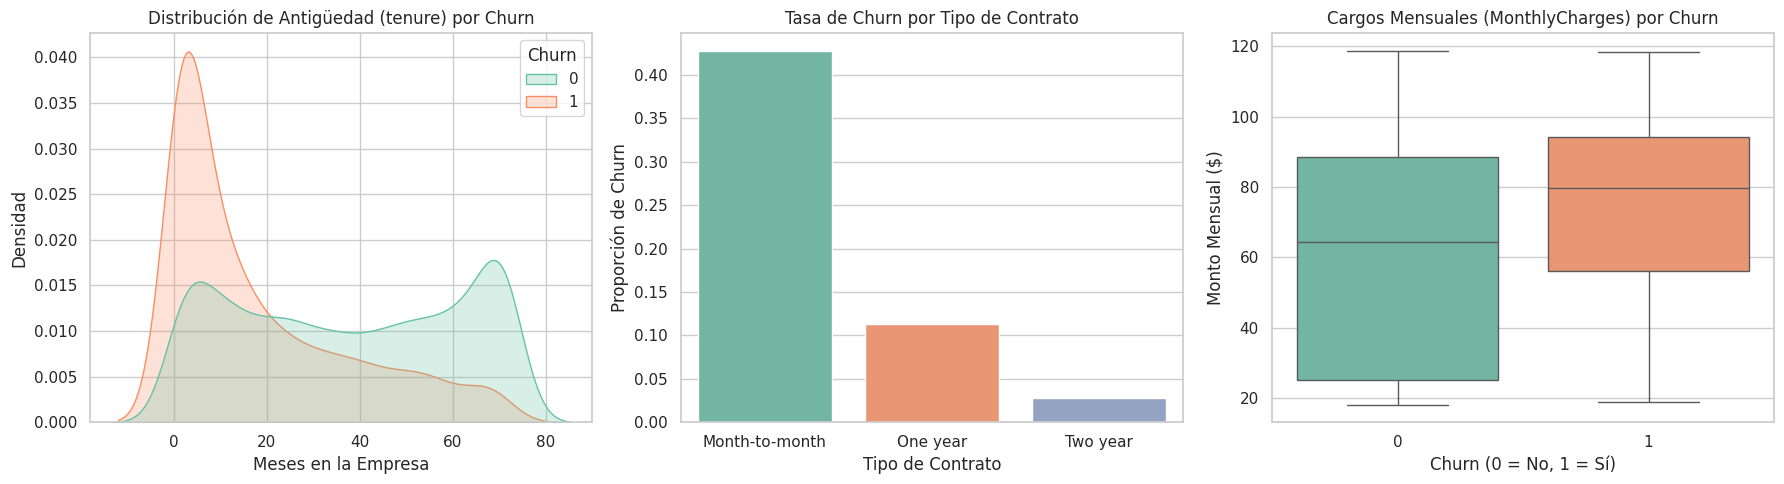

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 5))

# 1. Gráfica de Antigüedad (tenure) vs Churn
plt.subplot(1, 3, 1)
sns.kdeplot(data=df_clean, x='tenure', hue='Churn', common_norm=False, palette='Set2', fill=True)
plt.title('Distribución de Antigüedad (tenure) por Churn')
plt.xlabel('Meses en la Empresa')
plt.ylabel('Densidad')

# 2. Gráfica de Tipo de Contrato vs Churn
plt.subplot(1, 3, 2)
sns.barplot(data=df_clean, x='Contract', y='Churn', palette='Set2', errorbar=None)
plt.title('Tasa de Churn por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Proporción de Churn')

# 3. Gráfica de Cargos Mensuales vs Churn
plt.subplot(1, 3, 3)
sns.boxplot(data=df_clean, x='Churn', y='MonthlyCharges', palette='Set2')
plt.title('Cargos Mensuales (MonthlyCharges) por Churn')
plt.xlabel('Churn (0 = No, 1 = Sí)')
plt.ylabel('Monto Mensual ($)')

plt.tight_layout()
plt.show()

# 4. Codificación de Variables (Encoding) y Train/Test Split

In [7]:
from sklearn.model_selection import train_test_split

# 1. Separar características (X) y variable objetivo (y)
X = df_clean.drop(columns=['Churn'])
y = df_clean['Churn']

# 2. Codificación de variables categóricas (One-Hot Encoding)
X_encoded = pd.get_dummies(X, drop_first=True)

# 3. División en conjuntos de Entrenamiento y Prueba (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Características generadas (columnas): {X_encoded.shape[1]}")
print(f"Registros en Train: {X_train.shape[0]} | Registros en Test: {X_test.shape[0]}")

Características generadas (columnas): 30
Registros en Train: 5634 | Registros en Test: 1409


# 5. Modelado Predictivo y Seguimiento de Experimentos (MLflow)

In [8]:
# Instalar MLflow en Colab
!pip install -q mlflow

import mlflow
import mlflow.sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# Configurar el experimento en MLflow
mlflow.set_experiment("Telecom_Churn_Prediction") # Creo una carpeta virtual llamada Telecom_Churn_Prediction donde se organizarán todas las corridas de pruebas.
print("MLflow configurado correctamente.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1

2026/08/09 21:56:29 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/09 21:56:29 INFO mlflow.store.db.utils: Updating database tables
2026/08/09 21:56:33 INFO mlflow.tracking.fluent: Experiment with name 'Telecom_Churn_Prediction' does not exist. Creating a new experiment.


MLflow configurado correctamente.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
2026/08/09 22:05:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


=== Logistic_Regression_Balanced ===
ROC-AUC Score: 0.8420

Reporte de Clasificación:
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



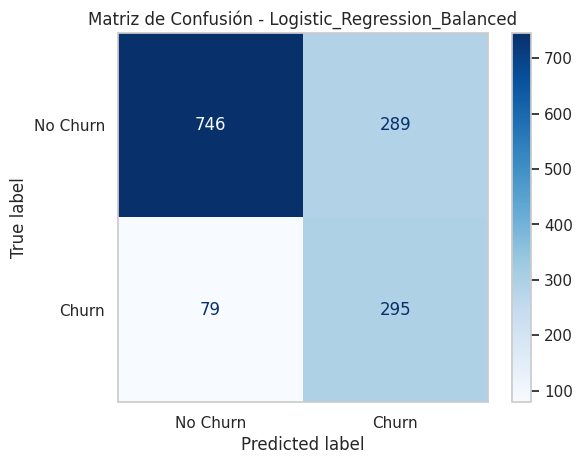

2026/08/09 22:06:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


=== Random_Forest_Balanced ===
ROC-AUC Score: 0.8209

Reporte de Clasificación:
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1035
       Churn       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



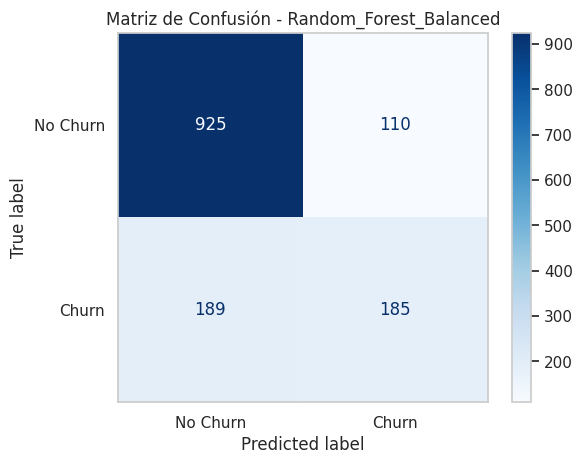

In [10]:
# Función para entrenar, evaluar y registrar un modelo en MLflow
def train_and_log_model(model, model_name, X_tr, y_tr, X_te, y_te):
    with mlflow.start_run(run_name=model_name):
        # 1. Entrenar modelo
        model.fit(X_tr, y_tr)

        # 2. Predicciones
        y_pred = model.predict(X_te)
        y_proba = model.predict_proba(X_te)[:, 1]

        # 3. Métricas
        roc_auc = roc_auc_score(y_te, y_proba)

        # 4. Registrar parámetros y métricas en MLflow
        mlflow.log_param("model_type", model_name)
        if hasattr(model, 'class_weight'):
            mlflow.log_param("class_weight", str(model.class_weight))

        mlflow.log_metric("roc_auc", roc_auc)

        # Guardar el modelo en MLflow
        mlflow.sklearn.log_model(model, artifact_path="model")

        print(f"=== {model_name} ===")
        print(f"ROC-AUC Score: {roc_auc:.4f}\n")
        print("Reporte de Clasificación:")
        print(classification_report(y_te, y_pred, target_names=['No Churn', 'Churn']))

        # Visualizar Matriz de Confusión
        cm = confusion_matrix(y_te, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
        disp.plot(cmap='Blues')
        plt.title(f"Matriz de Confusión - {model_name}")
        plt.grid(False)
        plt.show()

# Experiment 1: Logistic Regression (Baseline compensado)
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
train_and_log_model(lr_model, "Logistic_Regression_Balanced", X_train, y_train, X_test, y_test)

# Experiment 2: Random Forest (Modelo Ensamble)
rf_model = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
train_and_log_model(rf_model, "Random_Forest_Balanced", X_train, y_train, X_test, y_test)

"Aunque Random Forest muestra un Accuracy superior (79% vs 74%), en un problema de Churn el Accuracy es una métrica engañosa. Regresión Logística superó a Random Forest con un ROC-AUC de 0.8420 y un Recall del 79%, logrando capturar a 295 de los 374 clientes en riesgo de cancelación."

# 6. Explicabilidad del Modelo e Impacto de Negocio (SHAP Values)
> En esta sección utilizamos **SHAP (SHapley Additive exPlanations)** para abrir la "caja negra" del modelo seleccionado (**Regresión Logística**) e identificar qué variables de comportamiento y servicio tienen mayor peso cuantitativo en la probabilidad de que un cliente cancele su suscripción.

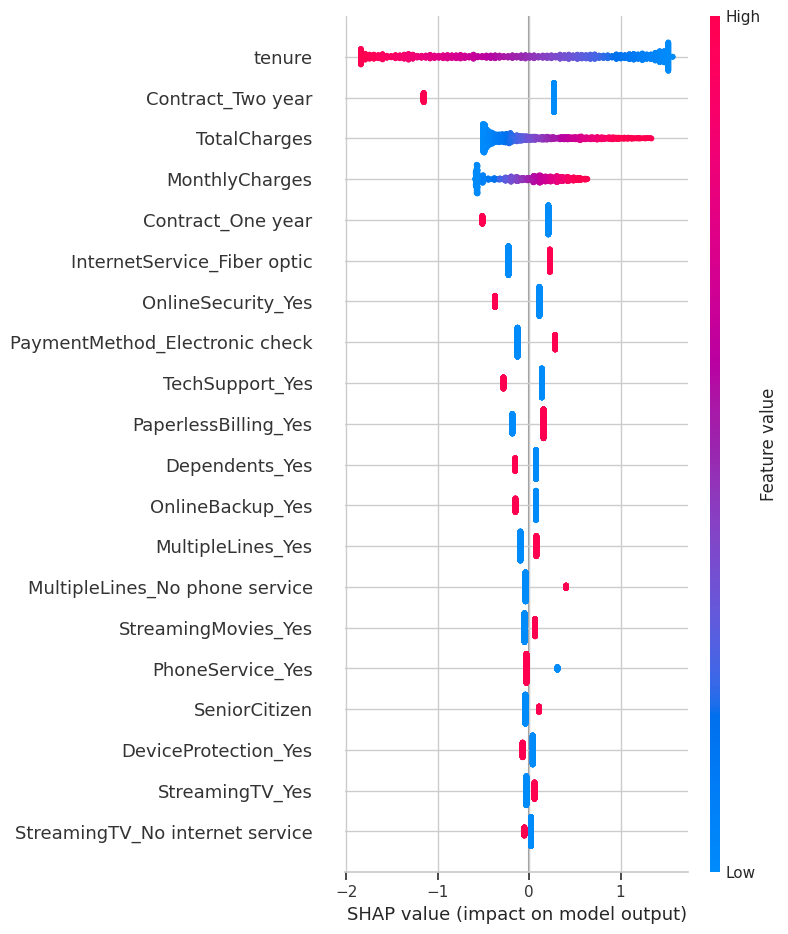

In [13]:
# 1. Instalar la librería SHAP
!pip install -q shap

import shap
import matplotlib.pyplot as plt

# 2. Convertir los datos a float para evitar errores de tipo booleano en NumPy/SHAP
X_train_shap = X_train.astype(float)
X_test_shap = X_test.astype(float)

# 3. Configurar el explicador para Regresión Logística
explainer = shap.LinearExplainer(lr_model, X_train_shap)
shap_values = explainer(X_test_shap)

# 4. Gráfico global de impacto de variables (Summary Plot)
shap.summary_plot(shap_values, X_test_shap)

# 7. Conclusiones y Recomendaciones de Negocio

### 📌 Hallazgos Técnicos y Estratégicos
* **Priorización de Métricas de Negocio:** Se seleccionó la **Regresión Logística con balanceo de pesos** (`ROC-AUC = 0.8420`) sobre Random Forest. Aunque Random Forest mostró un mayor *Accuracy* general (79%), la Regresión Logística maximizó el **Recall (79%)**, logrando capturar a **295 de los 374 clientes reales en riesgo** de cancelación.
* **Perfil de Fuga Identificado:** La probabilidad de Churn aumenta drásticamente en clientes con **menos de 12 meses de antigüedad**, contratos **mes a mes (*Month-to-month*)**, tarifas mensuales elevadas y servicio de **Fibra Óptica**.

---

### 🚀 Recomendaciones Comprables y Plan de Acción
1. **Programa de Retención Temprana (Onboarding):** Implementar campañas de fidelización y descuentos progresivos durante los primeros 12 meses de vida del cliente para superar la ventana crítica de abandono.
2. **Incentivos para Migración de Contratos:** Diseñar promociones exclusivas para convertir clientes con esquema *Month-to-month* a contratos de **1 o 2 años**, el mayor factor de blindaje detectado por el modelo.
3. **Empaquetamiento de Servicios (Bundling):** Ofrecer bonificaciones en *Online Security* y *Tech Support*, ya que el análisis SHAP demuestra que la adopción de estos servicios reduce significativamente la probabilidad de baja.
4. **Revisión del Producto Fibra Óptica:** Realizar una auditoría de satisfacción sobre los usuarios de Fibra Óptica para corregir problemas de percepción de precio o estabilidad del servicio.